# SML Exp - 4 (Part-2)

**Ridge and Lasso Regression Model**

In [5]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import operator
from sklearn.model_selection import GridSearchCV

In [6]:
# Loading the dataset
df=pd.read_csv(r"C:\Users\Yug\Downloads\ENB2012_data.xlsx - Φύλλο1.csv")
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


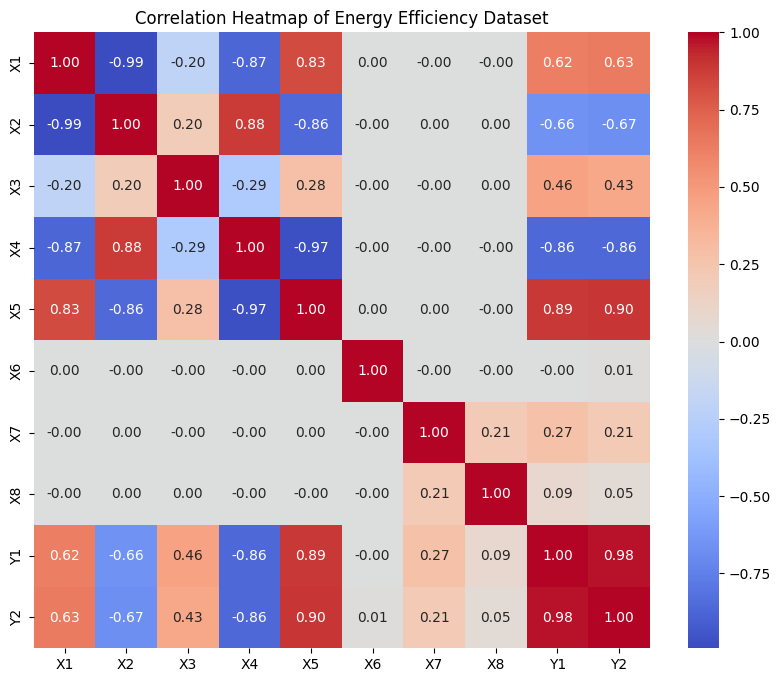

In [7]:
# Visualize correlations between features and targets using a heatmap   
import seaborn as sns
plt.figure(figsize=(10,8))
corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Correlation Heatmap of Energy Efficiency Dataset")
plt.show()


In [8]:
# Transforming into X and Y
X = df[['X1','X2','X3','X4','X5','X6','X7','X8']]
y1=df['Y1']
y2=df['Y2']
print(X)
print(y1)
print(y2)

       X1     X2     X3      X4   X5  X6   X7  X8
0    0.98  514.5  294.0  110.25  7.0   2  0.0   0
1    0.98  514.5  294.0  110.25  7.0   3  0.0   0
2    0.98  514.5  294.0  110.25  7.0   4  0.0   0
3    0.98  514.5  294.0  110.25  7.0   5  0.0   0
4    0.90  563.5  318.5  122.50  7.0   2  0.0   0
..    ...    ...    ...     ...  ...  ..  ...  ..
763  0.64  784.0  343.0  220.50  3.5   5  0.4   5
764  0.62  808.5  367.5  220.50  3.5   2  0.4   5
765  0.62  808.5  367.5  220.50  3.5   3  0.4   5
766  0.62  808.5  367.5  220.50  3.5   4  0.4   5
767  0.62  808.5  367.5  220.50  3.5   5  0.4   5

[768 rows x 8 columns]
0      15.55
1      15.55
2      15.55
3      15.55
4      20.84
       ...  
763    17.88
764    16.54
765    16.44
766    16.48
767    16.64
Name: Y1, Length: 768, dtype: float64
0      21.33
1      21.33
2      21.33
3      21.33
4      28.28
       ...  
763    21.40
764    16.88
765    17.11
766    16.61
767    16.03
Name: Y2, Length: 768, dtype: float64


In [9]:
# Train-Test split
X_train, X_test, y1_train, y1_test, y2_train, y2_test = train_test_split(
    X, y1, y2, test_size=0.2, random_state=42
)

In [10]:
# Scaling the values
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Y1**

In [11]:
# Define different alpha values to observe Ridge regression behavior 
alpha_values = [0, 0.1, 1, 10, 100]

print("RIDGE REGRESSION COEFFICIENTS (Y1)\n")
for alpha in alpha_values:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y1_train)
    print(f"Alpha = {alpha}")
    print(pd.Series(ridge.coef_, index=X.columns))
    print("-"*40)


RIDGE REGRESSION COEFFICIENTS (Y1)

Alpha = 0
X1   -6.517601e+00
X2    9.871654e+13
X3   -4.852446e+13
X4   -1.006864e+14
X5    7.037489e+00
X6    1.756222e-01
X7    2.948131e+00
X8    1.088289e-01
dtype: float64
----------------------------------------
Alpha = 0.1
X1   -6.370672
X2   -3.504665
X3    0.819390
X4   -3.830991
X5    7.255770
X6   -0.035852
X7    2.700066
X8    0.327530
dtype: float64
----------------------------------------
Alpha = 1
X1   -5.375465
X2   -2.848519
X3    0.991635
X4   -3.270694
X5    7.481422
X6   -0.035679
X7    2.699230
X8    0.328687
dtype: float64
----------------------------------------
Alpha = 10
X1   -2.588022
X2   -1.458356
X3    1.668960
X4   -2.234156
X5    7.085408
X6   -0.042850
X7    2.669587
X8    0.330346
dtype: float64
----------------------------------------
Alpha = 100
X1    0.138378
X2   -1.190999
X3    2.549072
X4   -2.396188
X5    4.104728
X6   -0.052213
X7    2.336783
X8    0.336586
dtype: float64
--------------------------------------

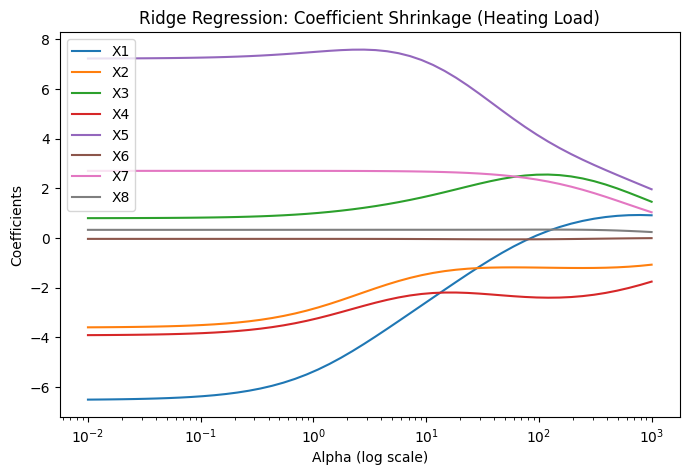

In [12]:
# Plot Ridge regression coefficient shrinkage path for different alpha values
# Generate alpha values on log scale
alphas = np.logspace(-2, 3, 50)
coefficients_path = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y1_train)
    coefficients_path.append(ridge.coef_)

coefficients_path = np.array(coefficients_path)

plt.figure(figsize=(8,5))
plt.plot(alphas, coefficients_path)
plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Coefficients")
plt.title("Ridge Regression: Coefficient Shrinkage (Heating Load)")
plt.legend(X.columns)
plt.show()

In [13]:
# Train Lasso regression models for Y1 using different alpha values
# Lasso Regression
print("LASSO REGRESSION COEFFICIENTS (Y1)\n")
for alpha in [0.001, 0.01, 0.1, 1]:
    lasso = Lasso(alpha=alpha, max_iter=5000)
    lasso.fit(X_train, y1_train)
    print(f"Alpha = {alpha}")
    print(pd.Series(lasso.coef_, index=X.columns))
    print("-"*40)


LASSO REGRESSION COEFFICIENTS (Y1)

Alpha = 0.001
X1   -6.347700
X2   -6.380801
X3    2.243946
X4   -0.856015
X5    7.274299
X6   -0.034706
X7    2.699697
X8    0.326718
dtype: float64
----------------------------------------
Alpha = 0.01
X1   -4.560196
X2   -0.000000
X3    0.000000
X4   -4.954486
X5    7.885140
X6   -0.023574
X7    2.697466
X8    0.321437
dtype: float64
----------------------------------------
Alpha = 0.1
X1   -0.000921
X2    0.000000
X3    2.160617
X4   -0.000000
X5    8.247621
X6   -0.000000
X7    2.635757
X8    0.247242
dtype: float64
----------------------------------------
Alpha = 1
X1    0.000000
X2   -0.000000
X3    1.429152
X4   -0.000000
X5    7.543810
X6   -0.000000
X7    1.775010
X8    0.000000
dtype: float64
----------------------------------------


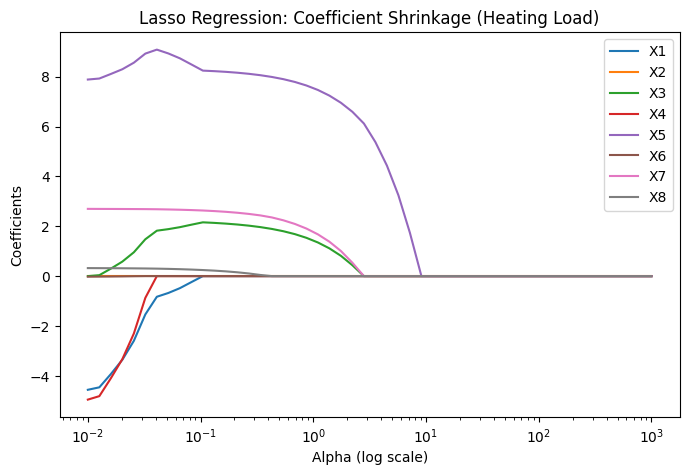

In [14]:
# Plot Lasso regression coefficient shrinkage path for different alpha values
coefficients_path = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=5000)
    lasso.fit(X_train, y1_train)
    coefficients_path.append(lasso.coef_)

coefficients_path = np.array(coefficients_path)

plt.figure(figsize=(8,5))
plt.plot(alphas, coefficients_path)
plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Coefficients")
plt.title("Lasso Regression: Coefficient Shrinkage (Heating Load)")
plt.legend(X.columns)
plt.show()


In [15]:
# Use GridSearchCV to find the optimal alpha value for Ridge regression (Y1)
param_grid = {'alpha': np.logspace(-3, 2, 20)}

ridge_cv = GridSearchCV(
    Ridge(),
    param_grid,
    scoring='neg_mean_squared_error'
)
ridge_cv.fit(X_train, y1_train)

print("Best Alpha (Ridge):", ridge_cv.best_params_['alpha'])


Best Alpha (Ridge): 0.12742749857031335


In [16]:
# Use GridSearchCV to find the optimal alpha value for Lasso regression (Y1)
lasso_cv = GridSearchCV(
    Lasso(max_iter=5000),
    param_grid,
    scoring='neg_mean_squared_error'
)
lasso_cv.fit(X_train, y1_train)

print("Best Alpha (Lasso):", lasso_cv.best_params_['alpha'])

Best Alpha (Lasso): 0.001


In [17]:
# Best models
best_ridge = ridge_cv.best_estimator_
best_lasso = lasso_cv.best_estimator_

# Predictions
ridge_pred = best_ridge.predict(X_test)
lasso_pred = best_lasso.predict(X_test)

# Errors
print("Ridge MSE:", mean_squared_error(y1_test, ridge_pred))
print("Lasso MSE:", mean_squared_error(y1_test, lasso_pred))

Ridge MSE: 9.160495642858242
Lasso MSE: 9.158164027616209


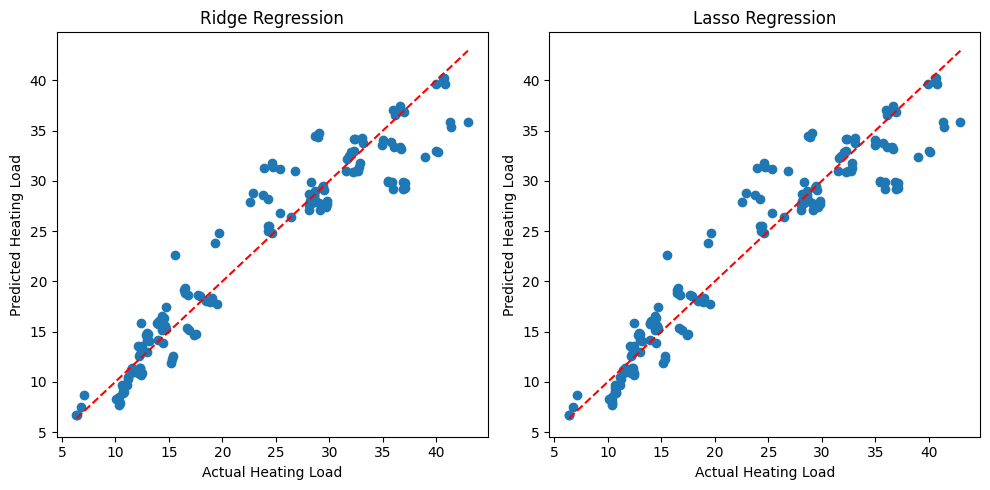

In [18]:
# Actual vs Predicted Plots
plt.figure(figsize=(10,5))

# Ridge
plt.subplot(1,2,1)
plt.scatter(y1_test, ridge_pred)
plt.plot([y1_test.min(), y1_test.max()],
         [y1_test.min(), y1_test.max()], 'r--')
plt.xlabel("Actual Heating Load")
plt.ylabel("Predicted Heating Load")
plt.title("Ridge Regression")

# Lasso
plt.subplot(1,2,2)
plt.scatter(y1_test, lasso_pred)
plt.plot([y1_test.min(), y1_test.max()],
         [y1_test.min(), y1_test.max()], 'r--')
plt.xlabel("Actual Heating Load")
plt.ylabel("Predicted Heating Load")
plt.title("Lasso Regression")

plt.tight_layout()
plt.show()

**Y2**

In [19]:
# Train Ridge regression models for Y2 using different alpha values
alpha_values = [0, 0.1, 1, 10, 100]

print("RIDGE REGRESSION COEFFICIENTS (Y2)\n")
for alpha in alpha_values:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train, y2_train)
    print(f"Alpha = {alpha}")
    print(pd.Series(ridge_model.coef_, index=X.columns))
    print("-"*40)

RIDGE REGRESSION COEFFICIENTS (Y2)

Alpha = 0
X1   -7.487886e+00
X2    1.020189e+14
X3   -5.014773e+13
X4   -1.040547e+14
X5    6.895912e+00
X6    2.797910e-01
X7    2.238549e+00
X8   -1.735071e-01
dtype: float64
----------------------------------------
Alpha = 0.1
X1   -7.314126
X2   -4.019068
X3    0.165818
X4   -4.020350
X5    7.130417
X6    0.061256
X7    1.982380
X8    0.052564
dtype: float64
----------------------------------------
Alpha = 1
X1   -6.140222
X2   -3.234244
X3    0.364910
X4   -3.346831
X5    7.421348
X6    0.061461
X7    1.983115
X8    0.054162
dtype: float64
----------------------------------------
Alpha = 10
X1   -2.918145
X2   -1.560424
X3    1.126866
X4   -2.072973
X5    7.115860
X6    0.052386
X7    1.964976
X8    0.058167
dtype: float64
----------------------------------------
Alpha = 100
X1    0.066705
X2   -1.196782
X3    2.143003
X4   -2.206159
X5    4.010490
X6    0.026498
X7    1.719715
X8    0.083702
dtype: float64
--------------------------------------

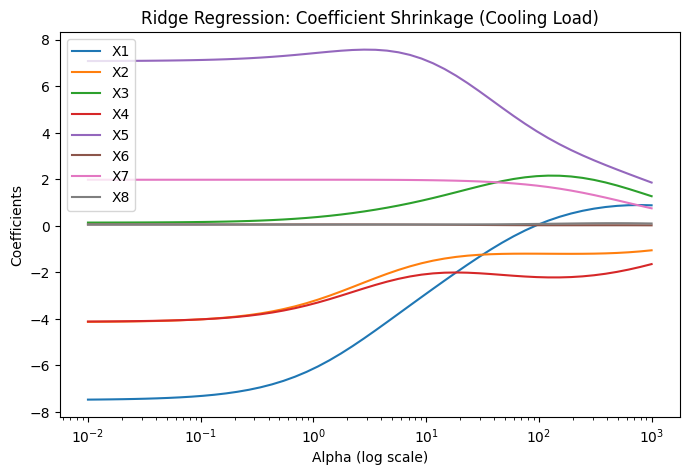

In [20]:
# Plot Ridge regression coefficient shrinkage path for Y2
alphas = np.logspace(-2, 3, 50)
coefficients_path = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y2_train)
    coefficients_path.append(ridge.coef_)

coefficients_path = np.array(coefficients_path)

plt.figure(figsize=(8,5))
plt.plot(alphas, coefficients_path)
plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Coefficients")
plt.title("Ridge Regression: Coefficient Shrinkage (Cooling Load)")
plt.legend(X.columns)
plt.show()

In [21]:
# Train Lasso regression models for Y2 using different alpha values
print("LASSO REGRESSION COEFFICIENTS (Y2)\n")
for alpha in [0.001, 0.01, 0.1, 1]:
    lasso_model = Lasso(alpha=alpha, max_iter=5000)
    lasso_model.fit(X_train, y2_train)
    print(f"Alpha = {alpha}")
    print(pd.Series(lasso_model.coef_, index=X.columns))
    print("-"*40)

LASSO REGRESSION COEFFICIENTS (Y2)

Alpha = 0.001
X1   -7.319459
X2   -7.188675
X3    1.720424
X4   -0.785586
X5    7.137771
X6    0.060379
X7    1.981870
X8    0.051698
dtype: float64
----------------------------------------
Alpha = 0.01
X1   -5.506372
X2   -1.843643
X3   -0.000000
X4   -3.794511
X5    7.755579
X6    0.053480
X7    1.980264
X8    0.046534
dtype: float64
----------------------------------------
Alpha = 0.1
X1   -0.454977
X2    0.000000
X3    1.501138
X4   -0.000000
X5    8.343573
X6    0.000000
X7    1.916738
X8    0.000000
dtype: float64
----------------------------------------
Alpha = 1
X1    0.000000
X2   -0.000000
X3    0.983544
X4   -0.000000
X5    7.207206
X6    0.000000
X7    1.006322
X8    0.000000
dtype: float64
----------------------------------------


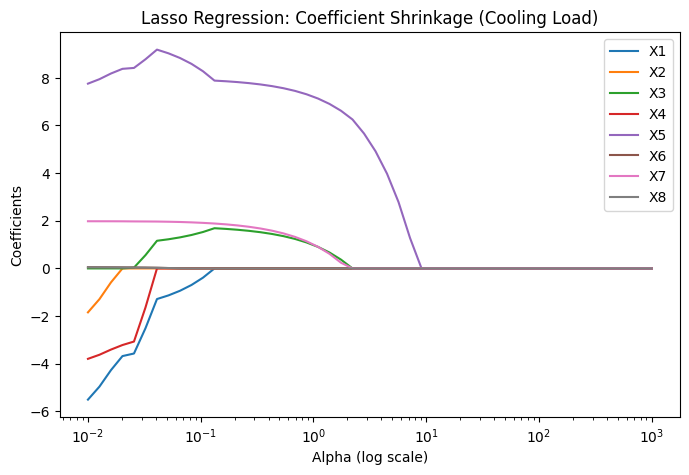

In [22]:
# Plot Lasso regression coefficient shrinkage path for Y2
coefficients_path = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=5000)
    lasso.fit(X_train, y2_train)
    coefficients_path.append(lasso.coef_)

coefficients_path = np.array(coefficients_path)

plt.figure(figsize=(8,5))
plt.plot(alphas, coefficients_path)
plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Coefficients")
plt.title("Lasso Regression: Coefficient Shrinkage (Cooling Load)")
plt.legend(X.columns)
plt.show()

In [23]:
# Use GridSearchCV to find the optimal alpha value for Ridge regression (Y2)
param_grid = {'alpha': np.logspace(-3, 2, 20)}

ridge_cv_y2 = GridSearchCV(
    Ridge(),
    param_grid,
    scoring='neg_mean_squared_error'
)
ridge_cv_y2.fit(X_train, y2_train)

print("Best Alpha (Ridge - Y2):", ridge_cv_y2.best_params_['alpha'])

Best Alpha (Ridge - Y2): 0.12742749857031335


In [24]:
# Use GridSearchCV to find the optimal alpha value for Lasso regression (Y2)
lasso_cv_y2 = GridSearchCV(
    Lasso(max_iter=5000),
    param_grid,
    scoring='neg_mean_squared_error'
)
lasso_cv_y2.fit(X_train, y2_train)

print("Best Alpha (Lasso - Y2):", lasso_cv_y2.best_params_['alpha'])

Best Alpha (Lasso - Y2): 0.001


In [25]:
# Evaluate best Ridge and Lasso models for Y2 using Mean Squared Error
best_ridge_y2 = ridge_cv_y2.best_estimator_
best_lasso_y2 = lasso_cv_y2.best_estimator_

ridge_pred_y2 = best_ridge_y2.predict(X_test)
lasso_pred_y2 = best_lasso_y2.predict(X_test)

print("Ridge MSE (Y2):", mean_squared_error(y2_test, ridge_pred_y2))
print("Lasso MSE (Y2):", mean_squared_error(y2_test, lasso_pred_y2))

Ridge MSE (Y2): 9.89624927888358
Lasso MSE (Y2): 9.894230224011949


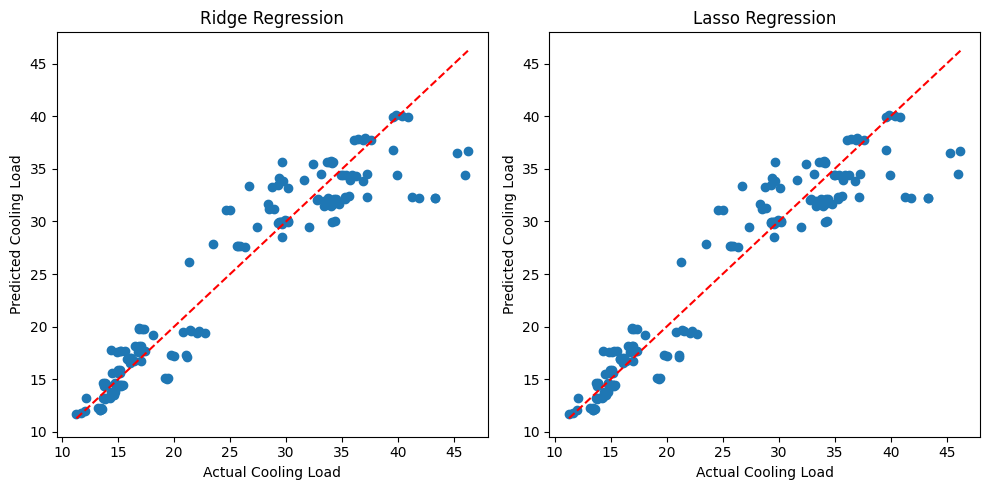

In [26]:
# Plot actual vs predicted values for Ridge and Lasso regression (Y2)
plt.figure(figsize=(10,5))

# Ridge
plt.subplot(1,2,1)
plt.scatter(y2_test, ridge_pred_y2)
plt.plot([y2_test.min(), y2_test.max()],
         [y2_test.min(), y2_test.max()], 'r--')
plt.xlabel("Actual Cooling Load")
plt.ylabel("Predicted Cooling Load")
plt.title("Ridge Regression")

# Lasso
plt.subplot(1,2,2)
plt.scatter(y2_test, lasso_pred_y2)
plt.plot([y2_test.min(), y2_test.max()],
         [y2_test.min(), y2_test.max()], 'r--')
plt.xlabel("Actual Cooling Load")
plt.ylabel("Predicted Cooling Load")
plt.title("Lasso Regression")

plt.tight_layout()
plt.show()

In [27]:
# Check overfitting/underfitting using train vs test error (Y1)
ridge_train_pred = best_ridge.predict(X_train)
ridge_test_pred = best_ridge.predict(X_test)

lasso_train_pred = best_lasso.predict(X_train)
lasso_test_pred = best_lasso.predict(X_test)

print("Ridge Train MSE:", mean_squared_error(y1_train, ridge_train_pred))
print("Ridge Test MSE:", mean_squared_error(y1_test, ridge_test_pred))

print("\nLasso Train MSE:", mean_squared_error(y1_train, lasso_train_pred))
print("Lasso Test MSE:", mean_squared_error(y1_test, lasso_test_pred))

Ridge Train MSE: 8.370475698880995
Ridge Test MSE: 9.160495642858242

Lasso Train MSE: 8.370415682221699
Lasso Test MSE: 9.158164027616209


In [28]:
# Check overfitting/underfitting using train vs test error (Y2)
ridge_train_pred = best_ridge.predict(X_train)
ridge_test_pred = best_ridge.predict(X_test)

lasso_train_pred = best_lasso.predict(X_train)
lasso_test_pred = best_lasso.predict(X_test)

print("Ridge Train MSE:", mean_squared_error(y2_train, ridge_train_pred))
print("Ridge Test MSE:", mean_squared_error(y2_test, ridge_test_pred))

print("\nLasso Train MSE:", mean_squared_error(y2_train, lasso_train_pred))
print("Lasso Test MSE:", mean_squared_error(y2_test, lasso_test_pred))

Ridge Train MSE: 16.397011046529535
Ridge Test MSE: 17.93238242485201

Lasso Train MSE: 16.394248017230552
Lasso Test MSE: 17.92530673333148


In [29]:
# Train AdaBoost Regressor to reduce MSE (Y1)
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=3),
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

ada.fit(X_train, y1_train)

ada_train_pred = ada.predict(X_train)
ada_test_pred = ada.predict(X_test)

print("AdaBoost Train MSE:", mean_squared_error(y1_train, ada_train_pred))
print("AdaBoost Test MSE:", mean_squared_error(y1_test, ada_test_pred))

AdaBoost Train MSE: 4.423910642997776
AdaBoost Test MSE: 5.064637294028426


In [30]:
# Train AdaBoost Regressor to reduce MSE (Y2)
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=3),
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

ada.fit(X_train, y2_train)

ada_train_pred = ada.predict(X_train)
ada_test_pred = ada.predict(X_test)

print("AdaBoost Train MSE:", mean_squared_error(y2_train, ada_train_pred))
print("AdaBoost Test MSE:", mean_squared_error(y2_test, ada_test_pred))

AdaBoost Train MSE: 5.829686063263697
AdaBoost Test MSE: 5.95619565063305


In [31]:
# Train XGBoost regressor to reduce MSE (Y1)
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb.fit(X_train, y1_train)

xgb_train_pred = xgb.predict(X_train)
xgb_test_pred = xgb.predict(X_test)

print("XGBoost Train MSE:", mean_squared_error(y1_train, xgb_train_pred))
print("XGBoost Test MSE:", mean_squared_error(y1_test, xgb_test_pred))


XGBoost Train MSE: 0.07611748423315974
XGBoost Test MSE: 0.16061582127041463


In [32]:
# Train XGBoost regressor to reduce MSE (Y2)
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb.fit(X_train, y2_train)

xgb_train_pred = xgb.predict(X_train)
xgb_test_pred = xgb.predict(X_test)

print("XGBoost Train MSE:", mean_squared_error(y2_train, xgb_train_pred))
print("XGBoost Test MSE:", mean_squared_error(y2_test, xgb_test_pred))


XGBoost Train MSE: 0.563744448882741
XGBoost Test MSE: 1.4413534190062278
